# 🏋️ Pipeline de Machine Learning para Análise de Desempenho de Atletas
## Prova de Conceito — Detecção de Anomalias e Comparação de Perfis

---

### Sobre este Notebook

Este notebook é a **prova de conceito (PoC)** do sistema analítico que futuramente alimentará uma aplicação web de monitoramento de atletas. Todo o raciocínio matemático, estatístico e computacional é documentado célula a célula, permitindo que qualquer leitor — independente de background técnico — compreenda não apenas *o que* o código faz, mas *por que* cada decisão foi tomada.

### Pipeline Completo

```
[1] Importação dos Dados
        ↓
[2] Validação e Limpeza (Data Quality)
        ↓
[3] Seleção e Pré-processamento de Variáveis
        ↓
[4] Padronização (StandardScaler)
        ↓
[5] Estatísticas Descritivas por Atleta
        ↓
[6] Isolation Forest — Detecção de Anomalias
        ↓
[7] Z-Score — Análise Matemática Passo a Passo
        ↓
[8] Classificação Combinada (IF + Z-Score)
        ↓
[9] Comparação entre Atletas e Sugestão de Substitutos
        ↓
[10] Resumo Executivo e Próximos Passos
```

### Glossário Rápido

| Termo | Significado |
|---|---|
| **Isolation Forest** | Algoritmo de ML que detecta sessões anômalas isolando pontos raros |
| **Z-Score** | Número de desvios padrão que um valor está afastado da média |
| **StandardScaler** | Técnica de normalização que transforma variáveis para média 0 e desvio 1 |
| **Anomalia** | Sessão cujo comportamento difere significativamente do padrão histórico do atleta |
| **Distância de Cosseno** | Medida de similaridade entre perfis de atletas (0 = idêntico, 2 = oposto) |


---
## Seção 1 — Importação das Bibliotecas

### Por que estas bibliotecas?

Cada biblioteca foi escolhida por uma razão específica dentro do pipeline:

- **`pandas`**: Manipulação tabular de dados (DataFrames). É o equivalente do Excel no Python — permite filtrar, agrupar, calcular e transformar dados tabulares com eficiência.
- **`numpy`**: Computação numérica de alta performance. O pandas usa numpy internamente; usamos diretamente para cálculos matriciais e vetorizados.
- **`matplotlib` / `seaborn`**: Visualização de dados. O seaborn é construído sobre o matplotlib e produz gráficos estatísticos com menos código.
- **`sklearn.preprocessing.StandardScaler`**: Implementa a padronização Z-score de forma vetorizada e eficiente, com suporte a *fit* em dados de treino e *transform* em novos dados (fundamental para produção).
- **`sklearn.ensemble.IsolationForest`**: Implementação otimizada do algoritmo Isolation Forest para detecção de anomalias não supervisionada.
- **`scipy.stats`**: Fornece funções estatísticas avançadas, incluindo cálculo de Z-scores com tratamento numérico robusto.
- **`sklearn.metrics.pairwise`**: Cálculo de distâncias e similaridades entre vetores de perfis de atletas.
- **`warnings`**: Suprime avisos não críticos que poluiriam a saída do notebook.


In [1]:
# ─────────────────────────────────────────────────────────
# IMPORTAÇÃO DAS BIBLIOTECAS
# ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
from scipy import stats

# Configurações de visualização
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Todas as bibliotecas importadas com sucesso!")
print(f"   pandas  {pd.__version__} | numpy {np.__version__}")


✅ Todas as bibliotecas importadas com sucesso!
   pandas  3.0.2 | numpy 2.4.4


---
## Seção 2 — Importação e Inspeção Inicial dos Dados

### Estrutura esperada da planilha

O arquivo `players.xlsx` contém dados exportados de um sistema de monitoramento físico (e.g., GPS wearables, plataformas como Catapult ou STATSports). Cada linha representa uma **sessão de treino ou partida** de um atleta, segmentada por período (e.g., "Whole Session", "First Half", "Second Half").

### Estratégia de importação

Utilizamos `pd.read_excel()` com detecção automática de tipos. Em seguida, realizamos uma inspeção inicial com:
- `.shape` → dimensões (linhas × colunas)
- `.dtypes` → tipo de dado por coluna
- `.head()` → primeiras linhas para conferência visual
- `.isnull().sum()` → contagem de valores ausentes por coluna

### Filtro de segmento

O pipeline utiliza apenas registros de **"Whole Session"** (sessão completa), pois:
1. Elimina dupla contagem (cada partida gera múltiplos segmentos: First Half, Second Half, Total of Segments etc.)
2. Garante comparabilidade entre sessões de duração completa
3. Fornece os valores agregados mais representativos do esforço total do atleta


In [2]:
# ─────────────────────────────────────────────────────────
# IMPORTAÇÃO DOS DADOS
# ─────────────────────────────────────────────────────────

# Caminho do arquivo — substitua pelo caminho correto se necessário
ARQUIVO = 'players.xlsx'

df_raw = pd.read_excel(ARQUIVO)

print(f"📊 Dimensões brutas: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas")
print(f"📅 Período dos dados: {df_raw['Start Date'].min().date()} → {df_raw['Start Date'].max().date()}")
print(f"👤 Atletas únicos: {df_raw['Athlete ID'].nunique()}")
print(f"📂 Segmentos disponíveis: {list(df_raw['Segment Name'].unique())}")


📊 Dimensões brutas: 3,012 linhas × 34 colunas
📅 Período dos dados: 2025-01-31 → 2025-11-22
👤 Atletas únicos: 26
📂 Segmentos disponíveis: ['Whole Session', 'Total of Segments', 'Second Half', 'First Half', 'Extra Time 1', 'Extra Time 2']


In [3]:
# ─────────────────────────────────────────────────────────
# VISUALIZAÇÃO INICIAL
# ─────────────────────────────────────────────────────────
print("\n🔍 Primeiras 3 linhas do dataset bruto:")
df_raw.head(3)



🔍 Primeiras 3 linhas do dataset bruto:


,Athlete ID,Athlete Position,Athlete Groups,Start Date,Start Time,Start Time (s),End Time (s),Week Start Date,Month Start Date,Segment Name,...,Accelerations,Decelerations,Percentage of Max Speed,Percentage of Raw Max Speed KPH,90% of Max Speed Events,90% of Max Speed Distance (m),90% of Max Speed Duration (secs),90% of Raw Max Speed Events,90% of Raw Max Speed Distance (m),90% of Raw Max Speed Duration (secs)
0,2240331969,Centre Attacking Midfielder,10s,2025-01-31,15:00:00,15:00:00,17:31:00,2025-01-27,2025-01-01,Whole Session,...,81.0,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2240331969,Centre Attacking Midfielder,10s,2025-01-31,15:00:00,15:00:00,17:31:00,2025-01-27,2025-01-01,Total of Segments,...,81.0,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2240331969,Centre Attacking Midfielder,10s,2025-01-31,16:19:00,16:19:00,17:31:00,2025-01-27,2025-01-01,Second Half,...,72.0,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ─────────────────────────────────────────────────────────
# FILTRO: APENAS "Whole Session"
# ─────────────────────────────────────────────────────────
# Cada evento (treino/partida) gera múltiplas linhas (First Half, Second Half, etc.)
# Para evitar dupla contagem e garantir comparabilidade, usamos apenas a sessão completa.

df_ws = df_raw[df_raw['Segment Name'] == 'Whole Session'].copy()
df_ws = df_ws.reset_index(drop=True)

print(f"✅ Após filtro 'Whole Session': {df_ws.shape[0]:,} registros de {df_ws['Athlete ID'].nunique()} atletas")

# Distribuição de sessões por atleta
dist = df_ws.groupby('Athlete ID').size().rename('Sessões')
print("\n📋 Sessões por atleta (Top 10):")
print(dist.sort_values(ascending=False).head(10).to_string())


✅ Após filtro 'Whole Session': 708 registros de 26 atletas

📋 Sessões por atleta (Top 10):
Athlete ID
2269191174    44
2240331969    44
1620716011    42
679795059     41
1072007304    41
3972058617    40
4043691916    40
1588115292    37
2533666538    35
1047619934    34


---
## Seção 3 — Validação da Integridade dos Dados (Data Quality)

### Por que a qualidade dos dados é crítica?

Em qualquer pipeline de Machine Learning, a qualidade dos dados de entrada determina diretamente a qualidade das previsões. Um modelo treinado com dados sujos produzirá detecções incorretas — fenômeno conhecido como **"garbage in, garbage out"**.

### Tipos de problemas tratados

| Problema | Causa Típica | Estratégia |
|---|---|---|
| **Valores ausentes (NaN)** | Sensor não registrou / exportação incompleta | Imputação pela mediana do atleta |
| **Valores zerados** | Sessão não iniciada / erro de registro | Tratados como ausentes se fisicamente impossíveis |
| **Duplicatas** | Exportação duplicada do sistema | Remoção pelo conjunto de identificadores-chave |
| **Tipos incorretos** | Datas como string, números como texto | Conversão explícita de tipos |
| **Inconsistências** | Ex.: distância > 0 mas duração = 0 | Detecção por regras de negócio |

### Estratégia de imputação: mediana por atleta

Utilizamos a **mediana** (e não a média) porque:
- É robusta a outliers — um único valor extremo não distorce a imputação
- Preserva a distribuição típica do atleta
- Evita introduzir informação de outros atletas na série histórica do indivíduo


🔎 Colunas com valores ausentes:
                                      Ausentes  % Ausentes
90% of Raw Max Speed Events                707       99.86
90% of Max Speed Duration (secs)           707       99.86
90% of Raw Max Speed Distance (m)          707       99.86
90% of Raw Max Speed Duration (secs)       707       99.86
90% of Max Speed Distance (m)              707       99.86
90% of Max Speed Events                    707       99.86
Percentage of Raw Max Speed KPH            502       70.90
Percentage of Max Speed                    291       41.10
Session Load                               291       41.10
Athlete Groups                              89       12.57
Athlete Position                            40        5.65
Workload Intensity                           8        1.13
Workload                                     8        1.13
Workload Volume                              8        1.13
High Intensity Running (m)                   6        0.85
Metres per Minute (m)   

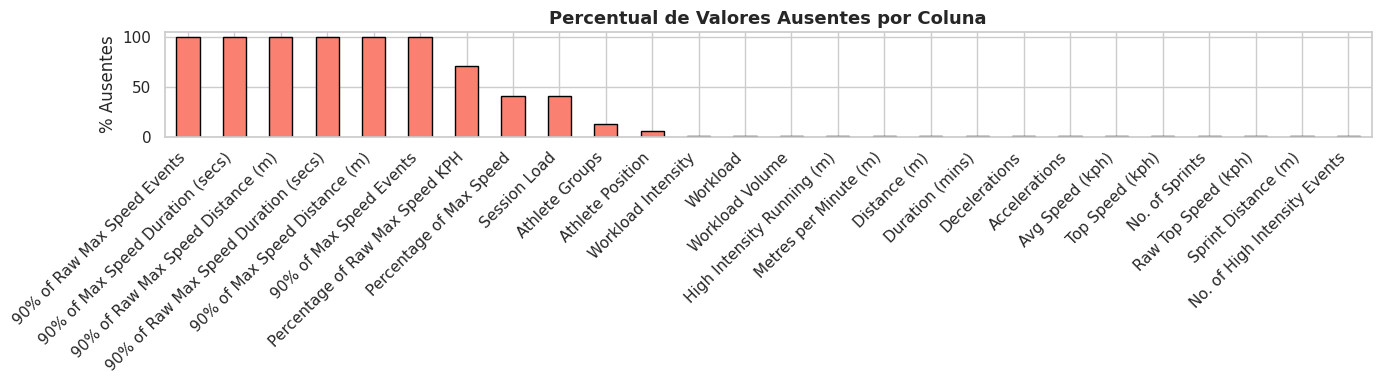

In [5]:
# ─────────────────────────────────────────────────────────
# PASSO 3.1 — INSPEÇÃO DE AUSENTES
# ─────────────────────────────────────────────────────────

ausentes = df_ws.isnull().sum()
pct_ausentes = (ausentes / len(df_ws) * 100).round(2)
resumo_ausentes = pd.DataFrame({
    'Ausentes': ausentes,
    '% Ausentes': pct_ausentes
}).query('Ausentes > 0').sort_values('% Ausentes', ascending=False)

print("🔎 Colunas com valores ausentes:")
print(resumo_ausentes.to_string())

# Visualização
fig, ax = plt.subplots(figsize=(14, 4))
resumo_ausentes['% Ausentes'].plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
ax.set_title('Percentual de Valores Ausentes por Coluna', fontsize=13, fontweight='bold')
ax.set_ylabel('% Ausentes')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [6]:
# ─────────────────────────────────────────────────────────
# PASSO 3.2 — VERIFICAÇÃO DE DUPLICATAS
# ─────────────────────────────────────────────────────────
# Identificador único de uma sessão = Atleta + Data + Segmento

chave_dedup = ['Athlete ID', 'Start Date', 'Segment Name']
n_duplicatas = df_ws.duplicated(subset=chave_dedup).sum()
print(f"♻️  Duplicatas encontradas: {n_duplicatas}")

if n_duplicatas > 0:
    df_ws = df_ws.drop_duplicates(subset=chave_dedup, keep='first')
    print(f"   → {n_duplicatas} registros duplicados removidos.")
else:
    print("   → Nenhuma duplicata encontrada. ✅")


♻️  Duplicatas encontradas: 196
   → 196 registros duplicados removidos.


In [7]:
# ─────────────────────────────────────────────────────────
# PASSO 3.3 — VERIFICAÇÃO DE ZEROS FISICAMENTE IMPLAUSÍVEIS
# ─────────────────────────────────────────────────────────
# Algumas colunas não devem ser zero em uma sessão completa registrada.
# Ex.: distância = 0 em uma sessão de 90min é suspeito (sensor falhou?).

cols_nao_zero = ['Distance (m)', 'Duration (mins)']
for col in cols_nao_zero:
    n_zeros = (df_ws[col] == 0).sum()
    if n_zeros > 0:
        print(f"⚠️  '{col}': {n_zeros} registros com valor zero → serão convertidos para NaN")
        df_ws[col] = df_ws[col].replace(0, np.nan)
    else:
        print(f"✅ '{col}': sem zeros problemáticos")


⚠️  'Distance (m)': 13 registros com valor zero → serão convertidos para NaN
✅ 'Duration (mins)': sem zeros problemáticos


In [8]:
# ─────────────────────────────────────────────────────────
# PASSO 3.4 — VERIFICAÇÃO DE INCONSISTÊNCIAS LÓGICAS
# ─────────────────────────────────────────────────────────
# Regra de negócio: Sprint Distance ≤ Distance (m)
# Um atleta não pode percorrer mais em sprint do que a distância total.

inconsist = df_ws[df_ws['Sprint Distance (m)'] > df_ws['Distance (m)']].shape[0]
print(f"🔎 Inconsistências (Sprint > Distância Total): {inconsist} registros")

# Regra: Top Speed ≥ Avg Speed
inconsist2 = df_ws[df_ws['Top Speed (kph)'] < df_ws['Avg Speed (kph)']].shape[0]
print(f"🔎 Inconsistências (Top Speed < Avg Speed): {inconsist2} registros")


🔎 Inconsistências (Sprint > Distância Total): 0 registros
🔎 Inconsistências (Top Speed < Avg Speed): 0 registros


In [9]:
# ─────────────────────────────────────────────────────────
# PASSO 3.5 — IMPUTAÇÃO POR MEDIANA DO ATLETA
# ─────────────────────────────────────────────────────────
# Para variáveis numéricas com ausentes, imputamos pela mediana histórica
# de cada atleta individualmente. Isso preserva o perfil individual
# e evita que dados de outros atletas contaminem a série do jogador.

COLUNAS_FISICAS = [
    'Duration (mins)', 'Workload', 'Distance (m)',
    'Metres per Minute (m)', 'High Intensity Running (m)',
    'Sprint Distance (m)', 'Raw Top Speed (kph)', 'No. of Sprints',
    'Top Speed (kph)', 'Avg Speed (kph)',
    'Accelerations', 'Decelerations',
    'No. of High Intensity Events', 'Session Load'
]

# Colunas efetivamente disponíveis
COLUNAS_FISICAS = [c for c in COLUNAS_FISICAS if c in df_ws.columns]

antes = df_ws[COLUNAS_FISICAS].isnull().sum().sum()

df_ws[COLUNAS_FISICAS] = df_ws.groupby('Athlete ID')[COLUNAS_FISICAS].transform(
    lambda x: x.fillna(x.median())
)

# Se ainda houver NaN (atleta com 100% ausente na coluna), usa mediana global
df_ws[COLUNAS_FISICAS] = df_ws[COLUNAS_FISICAS].fillna(df_ws[COLUNAS_FISICAS].median())

depois = df_ws[COLUNAS_FISICAS].isnull().sum().sum()
print(f"🔧 Valores ausentes nas colunas físicas: {antes} → {depois}")
print(f"✅ Dataset limpo: {df_ws.shape[0]} registros prontos para análise")


🔧 Valores ausentes nas colunas físicas: 293 → 0
✅ Dataset limpo: 512 registros prontos para análise


---
## Seção 4 — Seleção e Pré-processamento das Variáveis de Desempenho

### Critérios para seleção de variáveis

Nem todas as colunas são úteis para o modelo de detecção de anomalias. Selecionamos variáveis que:

1. **Representam carga física real** — mensuráveis por sensores GPS/inerciais
2. **Têm interpretação esportiva clara** — o analista precisa entender o que o modelo está sinalizando
3. **Possuem variabilidade suficiente** — variáveis constantes não contribuem para detecção de anomalias
4. **Não são redundantes** — evitamos incluir variáveis altamente correlacionadas que "pesariam duplo" no modelo

### Variáveis selecionadas e sua interpretação esportiva

| Variável | Unidade | Interpretação |
|---|---|---|
| `Workload` | UA (unidade arbitrária) | Carga total percebida da sessão |
| `Distance (m)` | metros | Volume de trabalho aeróbico total |
| `Metres per Minute (m)` | m/min | Intensidade relativa (ritmo médio) |
| `High Intensity Running (m)` | metros | Volume de corrida de alta intensidade |
| `Sprint Distance (m)` | metros | Volume de sprints (velocidade máxima) |
| `Top Speed (kph)` | km/h | Pico de velocidade atingido (capacidade anaeróbica) |
| `Avg Speed (kph)` | km/h | Velocidade média (resistência aeróbica) |
| `Accelerations` | count | Demanda neuromuscular de aceleração |
| `Decelerations` | count | Demanda neuromuscular de desaceleração |
| `No. of Sprints` | count | Número de esforços máximos realizados |
| `Duration (mins)` | minutos | Duração da sessão (contextualizador) |


In [10]:
# ─────────────────────────────────────────────────────────
# SELEÇÃO FINAL DAS VARIÁVEIS DO MODELO
# ─────────────────────────────────────────────────────────

FEATURES = [
    'Workload',
    'Distance (m)',
    'Metres per Minute (m)',
    'High Intensity Running (m)',
    'Sprint Distance (m)',
    'Top Speed (kph)',
    'Avg Speed (kph)',
    'Accelerations',
    'Decelerations',
    'No. of Sprints',
    'Duration (mins)'
]

# Verificar disponibilidade
FEATURES = [f for f in FEATURES if f in df_ws.columns]
print(f"✅ Variáveis selecionadas ({len(FEATURES)}):")
for i, f in enumerate(FEATURES, 1):
    print(f"   {i:2d}. {f}")


✅ Variáveis selecionadas (11):
    1. Workload
    2. Distance (m)
    3. Metres per Minute (m)
    4. High Intensity Running (m)
    5. Sprint Distance (m)
    6. Top Speed (kph)
    7. Avg Speed (kph)
    8. Accelerations
    9. Decelerations
   10. No. of Sprints
   11. Duration (mins)


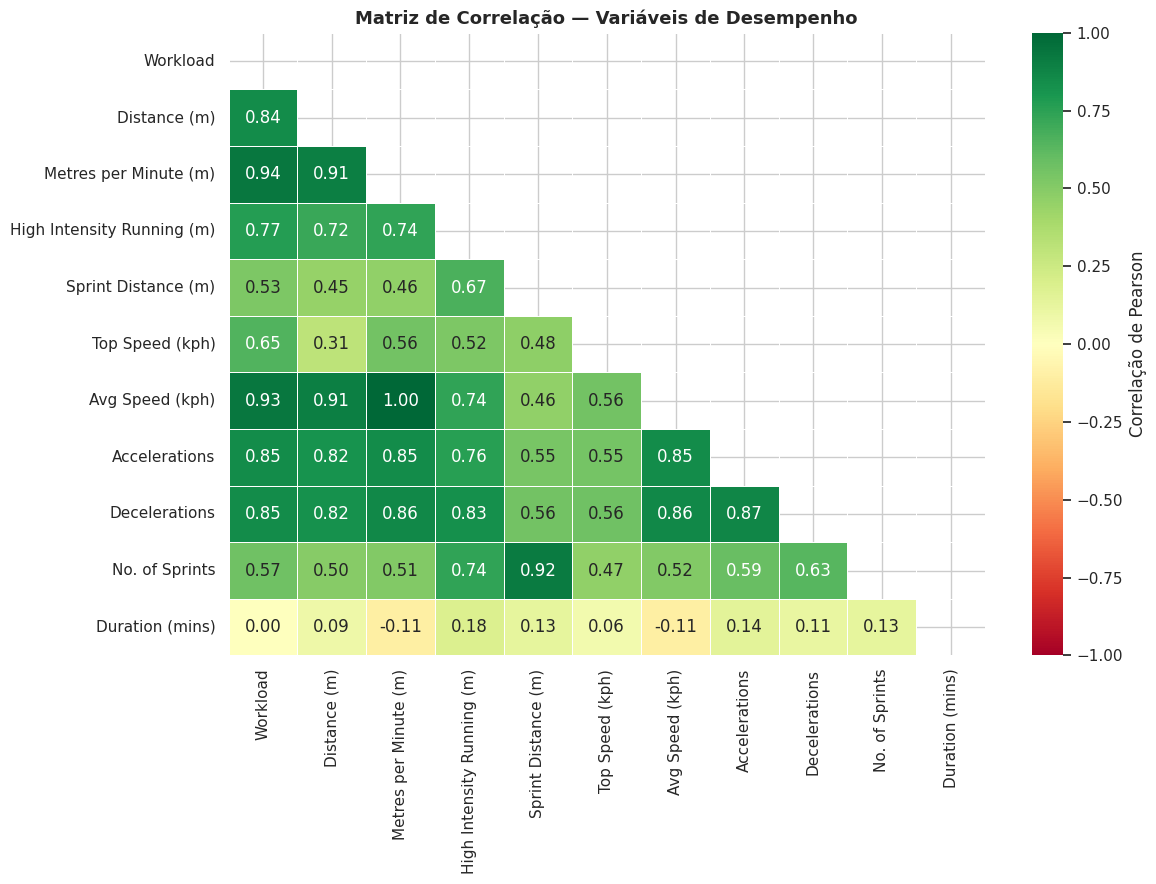


💡 Interpretação: Valores próximos de 1.0 indicam alta correlação positiva (as variáveis
   crescem juntas). Ex.: Distance e Duration correlacionadas sugere que sessões mais longas
   naturalmente acumulam mais distância — faz sentido esportivamente.


In [11]:
# ─────────────────────────────────────────────────────────
# ANÁLISE DE CORRELAÇÃO ENTRE AS VARIÁVEIS
# ─────────────────────────────────────────────────────────
# O heatmap de correlação nos ajuda a entender redundâncias.
# Variáveis com correlação > 0.95 poderiam ser removidas para evitar
# multicolinearidade, mas no Isolation Forest isso é menos crítico
# pois o algoritmo não assume distribuição específica nem calcula coeficientes.

corr_matrix = df_ws[FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Correlação de Pearson'}
)
ax.set_title('Matriz de Correlação — Variáveis de Desempenho', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Interpretação: Valores próximos de 1.0 indicam alta correlação positiva (as variáveis")
print("   crescem juntas). Ex.: Distance e Duration correlacionadas sugere que sessões mais longas")
print("   naturalmente acumulam mais distância — faz sentido esportivamente.")


---
## Seção 5 — Padronização com StandardScaler

### O problema das escalas diferentes

As variáveis físicas possuem escalas completamente diferentes:
- `Distance (m)` pode variar de 3.000 a 15.000 metros
- `No. of Sprints` varia de 0 a 30
- `Top Speed (kph)` varia de 20 a 40 km/h

Se alimentarmos o modelo com essas variáveis brutas, **variáveis de maior magnitude dominarão o cálculo de distâncias**, distorcendo a detecção de anomalias. O StandardScaler resolve isso.

### Matemática do StandardScaler

Para cada variável $x$, a transformação padronizada $z$ é:

$$z = \frac{x - \mu}{\sigma}$$

Onde:
- $\mu$ = média da variável no conjunto de treinamento
- $\sigma$ = desvio padrão da variável no conjunto de treinamento
- $z$ = valor padronizado (Z-score)

### Propriedades após a transformação

- **Média = 0** para todas as variáveis
- **Desvio padrão = 1** para todas as variáveis
- **Distribuição preservada** — o StandardScaler não muda o formato da distribuição, apenas a escala
- **Interpretabilidade** — $z = 2$ significa "2 desvios padrão acima da média"

### Por que não usar MinMaxScaler?

O MinMaxScaler comprime os dados no intervalo [0, 1]. Porém, ele é **sensível a outliers**: um único valor extremo comprime todos os outros valores num intervalo pequeno. Como estamos justamente procurando outliers (anomalias), o StandardScaler é mais adequado.


In [12]:
# ─────────────────────────────────────────────────────────
# PADRONIZAÇÃO GLOBAL (para comparação entre atletas)
# ─────────────────────────────────────────────────────────
# Fitamos o scaler em TODOS os dados (todos os atletas juntos).
# Isso cria uma referência de escala global, útil para comparação entre jogadores.

scaler_global = StandardScaler()
X_global = df_ws[FEATURES].values
X_scaled_global = scaler_global.fit_transform(X_global)

df_scaled = df_ws[['Athlete ID', 'Start Date', 'Segment Name']].copy()
for i, feat in enumerate(FEATURES):
    df_scaled[feat + '_z'] = X_scaled_global[:, i]

print("📐 Estatísticas PÓS-padronização (devem ser média≈0, std≈1):")
stats_pos = pd.DataFrame(X_scaled_global, columns=FEATURES).describe().loc[['mean','std']]
print(stats_pos.round(4).to_string())


📐 Estatísticas PÓS-padronização (devem ser média≈0, std≈1):
      Workload  Distance (m)  Metres per Minute (m)  High Intensity Running (m)  Sprint Distance (m)  Top Speed (kph)  Avg Speed (kph)  Accelerations  Decelerations  No. of Sprints  Duration (mins)
mean    -0.000         0.000                 -0.000                       0.000               -0.000            0.000            0.000         -0.000         -0.000          -0.000            0.000
std      1.001         1.001                  1.001                       1.001                1.001            1.001            1.001          1.001          1.001           1.001            1.001


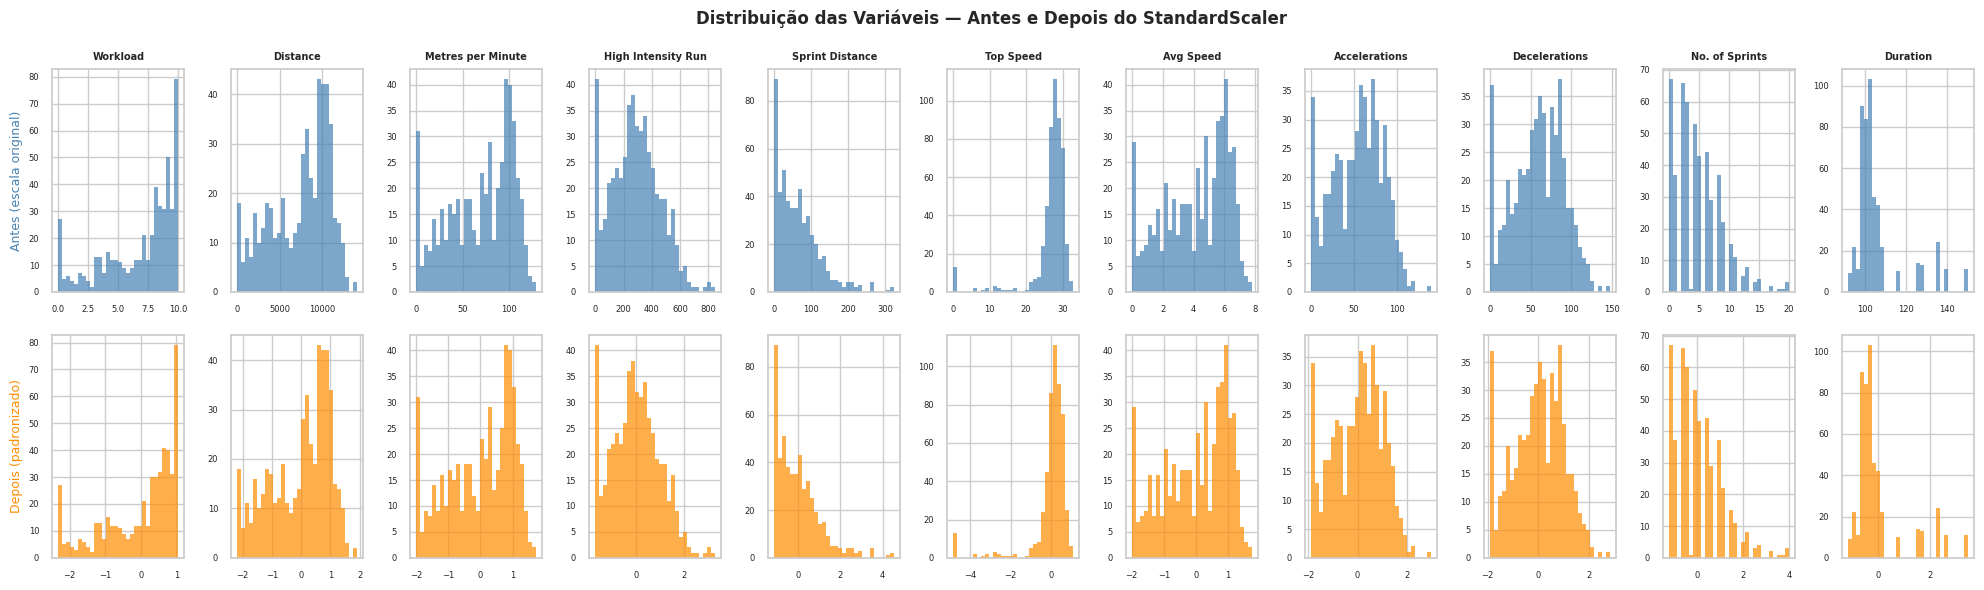


💡 Observe que o formato das distribuições é idêntico antes e depois.
   O StandardScaler apenas reposiciona a média em 0 e escala o desvio para 1.


In [13]:
# ─────────────────────────────────────────────────────────
# VISUALIZAÇÃO: ANTES E DEPOIS DA PADRONIZAÇÃO
# ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, len(FEATURES), figsize=(20, 6))

for i, feat in enumerate(FEATURES):
    # Antes
    axes[0, i].hist(df_ws[feat].dropna(), bins=30, color='steelblue', alpha=0.7, edgecolor='none')
    axes[0, i].set_title(feat.split('(')[0].strip()[:18], fontsize=7, fontweight='bold')
    axes[0, i].tick_params(labelsize=6)

    # Depois
    axes[1, i].hist(X_scaled_global[:, i], bins=30, color='darkorange', alpha=0.7, edgecolor='none')
    axes[1, i].tick_params(labelsize=6)

axes[0, 0].set_ylabel('Antes (escala original)', fontsize=9, color='steelblue')
axes[1, 0].set_ylabel('Depois (padronizado)', fontsize=9, color='darkorange')

fig.suptitle('Distribuição das Variáveis — Antes e Depois do StandardScaler', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Observe que o formato das distribuições é idêntico antes e depois.")
print("   O StandardScaler apenas reposiciona a média em 0 e escala o desvio para 1.")


---
## Seção 6 — Estatísticas Descritivas por Atleta

### Por que calcular estatísticas individualizadas?

O coração do sistema é a **comparação do atleta com seu próprio histórico**. Um sprint de 800m pode ser normal para um atacante, mas anômalo para um zagueiro. A análise individualizada respeita as características biomecânicas, posicionais e de aptidão de cada jogador.

### Métricas calculadas

| Métrica | Fórmula | Interpretação |
|---|---|---|
| **Média** ($\mu$) | $\frac{1}{n}\sum_{i=1}^{n} x_i$ | Valor "típico" do atleta na variável |
| **Mediana** | Valor central ordenado | Valor típico robusto a outliers |
| **Desvio Padrão** ($\sigma$) | $\sqrt{\frac{1}{n}\sum(x_i - \mu)^2}$ | Dispersão em torno da média |
| **Variância** ($\sigma^2$) | $\frac{1}{n}\sum(x_i - \mu)^2$ | Dispersão quadrática (sensível a outliers) |
| **Mínimo / Máximo** | $\min(x), \max(x)$ | Limites históricos observados |


In [14]:
# ─────────────────────────────────────────────────────────
# ESTATÍSTICAS DESCRITIVAS POR ATLETA
# ─────────────────────────────────────────────────────────

def estatisticas_atleta(df, features):
    """Calcula estatísticas descritivas para cada atleta."""
    resultados = []
    for athlete_id, grupo in df.groupby('Athlete ID'):
        for feat in features:
            serie = grupo[feat].dropna()
            if len(serie) < 2:
                continue
            resultados.append({
                'Athlete ID': athlete_id,
                'Variável': feat,
                'N Sessões': len(serie),
                'Média': serie.mean(),
                'Mediana': serie.median(),
                'Desvio Padrão': serie.std(ddof=1),   # ddof=1 = desvio amostral
                'Variância': serie.var(ddof=1),
                'Mínimo': serie.min(),
                'Máximo': serie.max(),
                'CV (%)': (serie.std(ddof=1) / serie.mean() * 100) if serie.mean() != 0 else np.nan
            })
    return pd.DataFrame(resultados)

df_stats = estatisticas_atleta(df_ws, FEATURES)

print(f"✅ Estatísticas calculadas: {df_stats.shape[0]} combinações atleta × variável")
print("\n📋 Exemplo — Athlete ID:", df_ws['Athlete ID'].unique()[0])
exemplo = df_stats[df_stats['Athlete ID'] == df_ws['Athlete ID'].unique()[0]]
print(exemplo[['Variável','N Sessões','Média','Desvio Padrão','CV (%)']].round(2).to_string(index=False))


✅ Estatísticas calculadas: 286 combinações atleta × variável

📋 Exemplo — Athlete ID: 2240331969
                  Variável  N Sessões   Média  Desvio Padrão  CV (%)
                  Workload         30    6.94           2.53   36.43
              Distance (m)         30 7028.03        2946.87   41.93
     Metres per Minute (m)         30   67.10          28.58   42.60
High Intensity Running (m)         30  281.17         148.45   52.80
       Sprint Distance (m)         30   56.10          46.40   82.71
           Top Speed (kph)         30   27.63           2.83   10.26
           Avg Speed (kph)         30    4.02           1.71   42.56
             Accelerations         30   51.73          23.77   45.94
             Decelerations         30   55.57          24.93   44.87
            No. of Sprints         30    4.10           3.00   73.13
           Duration (mins)         30  105.97          12.30   11.61


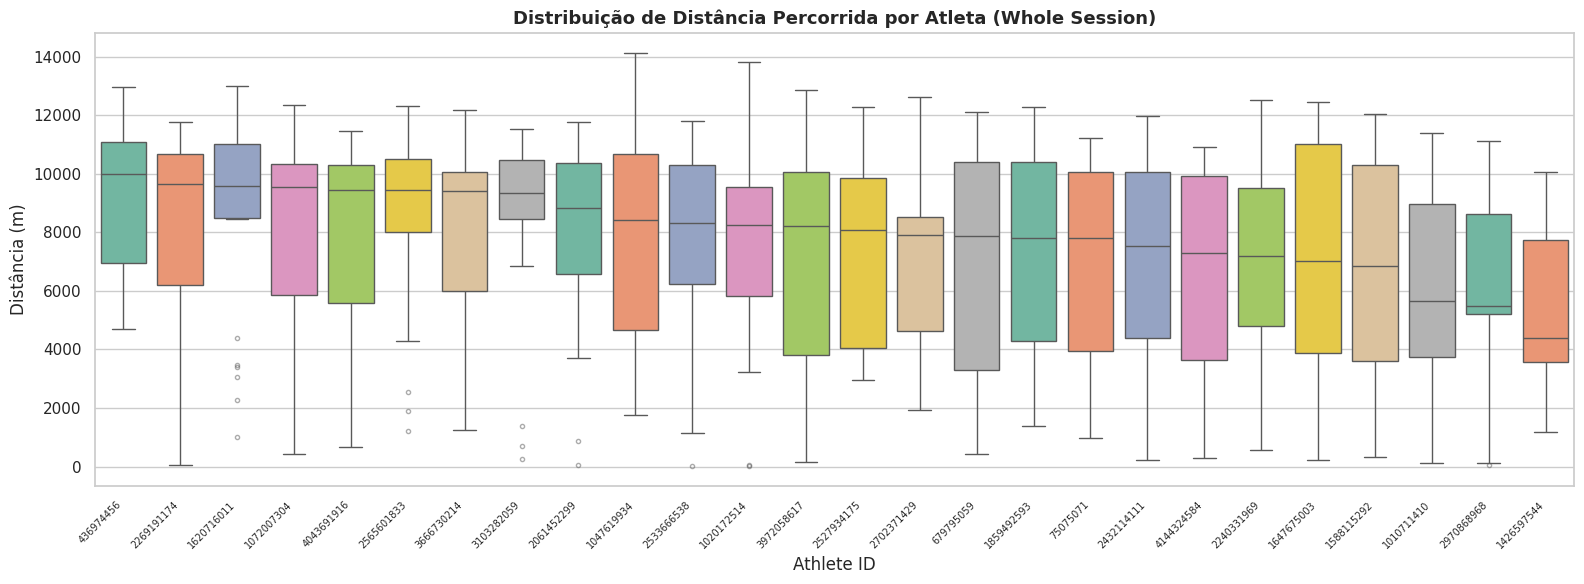

💡 Cada caixa representa o intervalo interquartil (IQR = Q3 - Q1) do atleta.
   A linha horizontal dentro da caixa é a mediana.
   Os pontos fora dos 'whiskers' são outliers potenciais — candidatos a anomalias.


In [15]:
# ─────────────────────────────────────────────────────────
# VISUALIZAÇÃO: BOXPLOT DE DISTÂNCIA POR ATLETA
# ─────────────────────────────────────────────────────────
# O boxplot mostra a distribuição completa (mediana, IQR, outliers)
# de uma variável para cada atleta — excelente para comparação visual.

fig, ax = plt.subplots(figsize=(16, 6))
order = df_ws.groupby('Athlete ID')['Distance (m)'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df_ws, x='Athlete ID', y='Distance (m)',
    order=order, ax=ax, palette='Set2',
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5}
)
ax.set_title('Distribuição de Distância Percorrida por Atleta (Whole Session)', fontsize=13, fontweight='bold')
ax.set_xlabel('Athlete ID')
ax.set_ylabel('Distância (m)')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

print("💡 Cada caixa representa o intervalo interquartil (IQR = Q3 - Q1) do atleta.")
print("   A linha horizontal dentro da caixa é a mediana.")
print("   Os pontos fora dos 'whiskers' são outliers potenciais — candidatos a anomalias.")


---
## Seção 7 — Isolation Forest: Detecção de Anomalias por Atleta

### O que é o Isolation Forest?

O **Isolation Forest** (Liu et al., 2008) é um algoritmo de detecção de anomalias não supervisionado baseado em árvores de decisão aleatórias. Diferente de outros métodos que *perfilam* o comportamento normal, o Isolation Forest *isola* pontos anômalos.

### Intuição matemática

**Premissa fundamental**: pontos anômalos são raros e diferentes do restante dos dados. Por isso, são mais fáceis de *isolar* — precisam de menos cortes aleatórios para ficarem sozinhos numa partição.

#### Como funciona, passo a passo:

1. **Seleciona aleatoriamente** uma feature (variável) $q$
2. **Seleciona aleatoriamente** um valor de corte $p$ entre $\min(q)$ e $\max(q)$
3. **Divide** os dados em dois grupos: $\{x : x_q < p\}$ e $\{x : x_q \geq p\}$
4. **Repete** recursivamente até cada ponto estar isolado
5. A **profundidade de isolamento** $h(x)$ é o número de cortes necessários para isolar $x$

**Pontos normais** → precisam de muitos cortes → profundidade alta  
**Pontos anômalos** → precisam de poucos cortes → profundidade baixa

#### Score de anomalia

O score $s(x, n)$ é normalizado entre 0 e 1:

$$s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}$$

Onde:
- $E[h(x)]$ = profundidade média de isolamento (média sobre todas as árvores)
- $c(n)$ = profundidade esperada para um ponto num dataset de tamanho $n$ (normalização)
- $s \to 1$: muito anômalo | $s \to 0.5$: normal | $s < 0.5$: definitivamente normal

### Parâmetros utilizados

| Parâmetro | Valor | Justificativa |
|---|---|---|
| `n_estimators` | 200 | 200 árvores → estimativa estável do score; mais árvores = mais estável mas mais lento |
| `contamination` | 0.1 | Assume que ~10% das sessões são anômalas (ajustável pelo analista) |
| `max_samples` | `'auto'` | Usa min(256, n_amostras) — padrão do paper original |
| `random_state` | 42 | Reprodutibilidade: mesmo random_state = mesmos resultados |

### Por que aplicar individualmente por atleta?

Aplicar o modelo globalmente (todos os atletas juntos) misturaria os perfis: uma distância de 12km seria normal para um lateral-esquerdo mas anômala para um zagueiro. Ao aplicar individualmente, o modelo aprende o **baseline único** de cada jogador.


In [16]:
# ─────────────────────────────────────────────────────────
# ISOLATION FOREST — APLICAÇÃO INDIVIDUAL POR ATLETA
# ─────────────────────────────────────────────────────────

def aplicar_isolation_forest(df, features, n_estimators=200, contamination=0.10, random_state=42):
    """
    Aplica Isolation Forest individualmente para cada atleta.
    
    Retorna DataFrame com colunas adicionais:
    - 'IF_Score': score de anomalia (-1 a 0, quanto mais negativo mais anômalo)
    - 'IF_Label': 1 = normal, -1 = anomalia (saída raw do sklearn)
    - 'IF_Anomalia': True se a sessão foi classificada como anomalia
    """
    resultados = []
    
    for athlete_id, grupo in df.groupby('Athlete ID'):
        grupo_c = grupo.copy()
        X = grupo_c[features].values
        n = len(X)
        
        if n < 5:
            # Poucos dados: não é possível treinar modelo confiável
            grupo_c['IF_Score'] = np.nan
            grupo_c['IF_Label'] = np.nan
            grupo_c['IF_Anomalia'] = False
            resultados.append(grupo_c)
            continue
        
        # Padronização LOCAL (por atleta) para o Isolation Forest
        # Importante: o scaler é fitado apenas nos dados do atleta,
        # garantindo que a detecção de anomalia seja relativa ao histórico dele.
        scaler_local = StandardScaler()
        X_scaled = scaler_local.fit_transform(X)
        
        # Treino e predição do modelo
        model = IsolationForest(
            n_estimators=n_estimators,
            contamination=contamination,
            max_samples='auto',
            random_state=random_state
        )
        model.fit(X_scaled)
        
        # score_samples retorna -score_anomalia (quanto mais negativo = mais anômalo)
        grupo_c['IF_Score'] = model.score_samples(X_scaled)
        grupo_c['IF_Label'] = model.predict(X_scaled)  # 1 = normal, -1 = anomalia
        grupo_c['IF_Anomalia'] = grupo_c['IF_Label'] == -1
        
        resultados.append(grupo_c)
    
    return pd.concat(resultados, ignore_index=True)

# Aplicar o modelo
df_if = aplicar_isolation_forest(df_ws, FEATURES)

# Sumário dos resultados
n_anomalias = df_if['IF_Anomalia'].sum()
pct_anomalias = n_anomalias / len(df_if) * 100
print(f"🔴 Sessões classificadas como anomalia: {n_anomalias} de {len(df_if)} ({pct_anomalias:.1f}%)")
print(f"🟢 Sessões normais: {(~df_if['IF_Anomalia']).sum()} ({100 - pct_anomalias:.1f}%)")

# Por atleta
por_atleta = df_if.groupby('Athlete ID')['IF_Anomalia'].agg(['sum','count'])
por_atleta.columns = ['Anomalias', 'Total']
por_atleta['% Anomalias'] = (por_atleta['Anomalias'] / por_atleta['Total'] * 100).round(1)
print("\n📊 Anomalias detectadas por atleta:")
print(por_atleta.sort_values('% Anomalias', ascending=False).head(10).to_string())


🔴 Sessões classificadas como anomalia: 62 de 512 (12.1%)
🟢 Sessões normais: 450 (87.9%)

📊 Anomalias detectadas por atleta:
            Anomalias  Total  % Anomalias
Athlete ID                               
1426597544          1      6         16.7
4144324584          2     12         16.7
2527934175          2     13         15.4
1859492593          2     14         14.3
1647675003          2     14         14.3
1010711410          2     14         14.3
3666730214          3     22         13.6
2061452299          2     15         13.3
679795059           3     23         13.0
436974456           1      8         12.5


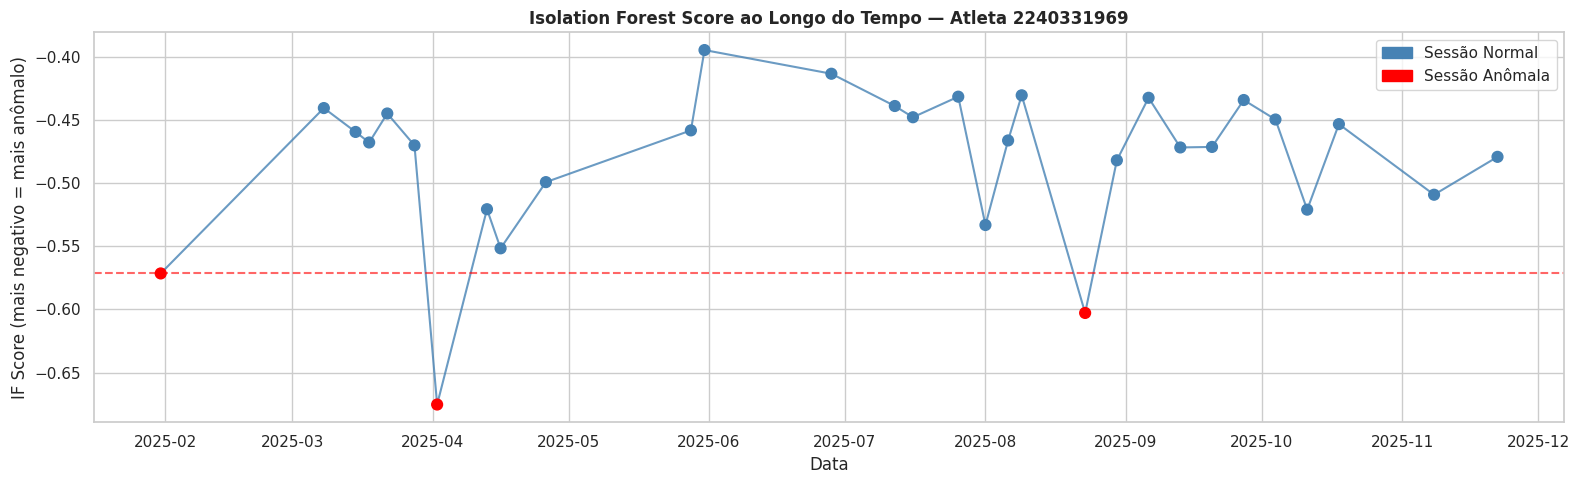


📋 Detalhes do atleta 2240331969:
   Total de sessões: 30
   Anomalias detectadas: 3
   Período analisado: 2025-01-31 → 2025-11-22


In [17]:
# ─────────────────────────────────────────────────────────
# VISUALIZAÇÃO: IF Score ao Longo do Tempo (Atleta Exemplo)
# ─────────────────────────────────────────────────────────

# Pegar o atleta com mais sessões para exemplo rico
atleta_exemplo = df_if.groupby('Athlete ID').size().idxmax()
df_atleta = df_if[df_if['Athlete ID'] == atleta_exemplo].sort_values('Start Date')

fig, ax = plt.subplots(figsize=(16, 5))

# Plot do score ao longo do tempo
ax.plot(df_atleta['Start Date'], df_atleta['IF_Score'], 
        color='steelblue', linewidth=1.5, alpha=0.8, label='IF Score')
ax.scatter(df_atleta['Start Date'], df_atleta['IF_Score'],
           c=df_atleta['IF_Anomalia'].map({True: 'red', False: 'steelblue'}),
           s=60, zorder=5)

# Linha de threshold
threshold = df_atleta[df_atleta['IF_Label'] == -1]['IF_Score'].max() if df_atleta['IF_Anomalia'].any() else None
if threshold:
    ax.axhline(y=threshold, color='red', linestyle='--', alpha=0.6, label=f'Limiar (≈{threshold:.3f})')

ax.set_title(f'Isolation Forest Score ao Longo do Tempo — Atleta {atleta_exemplo}', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('IF Score (mais negativo = mais anômalo)')

# Legenda manual
normal_patch = mpatches.Patch(color='steelblue', label='Sessão Normal')
anom_patch = mpatches.Patch(color='red', label='Sessão Anômala')
ax.legend(handles=[normal_patch, anom_patch])

plt.tight_layout()
plt.show()

print(f"\n📋 Detalhes do atleta {atleta_exemplo}:")
print(f"   Total de sessões: {len(df_atleta)}")
print(f"   Anomalias detectadas: {df_atleta['IF_Anomalia'].sum()}")
print(f"   Período analisado: {df_atleta['Start Date'].min().date()} → {df_atleta['Start Date'].max().date()}")


---
## Seção 8 — Z-Score: Demonstração Matemática Passo a Passo

### O que é o Z-Score?

O **Z-Score** (ou score padronizado) quantifica **quão distante** um valor específico está da média histórica do atleta, expressa em **unidades de desvio padrão**.

$$Z = \frac{x - \mu}{\sigma}$$

### Interpretação prática

| Z-Score | Interpretação |
|---|---|
| $Z = 0$ | Exatamente na média histórica |
| $Z = +1$ | 1 desvio padrão **acima** da média (≈ top 16% das sessões) |
| $Z = +2$ | 2 desvios padrão **acima** (≈ top 2.3%) — **Alta significativa** |
| $Z = -1$ | 1 desvio padrão **abaixo** (possível fadiga leve) |
| $Z = -2$ | 2 desvios padrão **abaixo** (≈ bottom 2.3%) — **Queda significativa** |
| $|Z| > 3$ | Evento extremamente raro (< 0.3% das sessões) — possível lesão ou problema |

### Thresholds adotados

- $|Z| \leq 1.5$: **Desempenho médio** — variação normal
- $Z > 1.5$: **Alta de desempenho** — o atleta está excedendo seu padrão histórico
- $Z < -1.5$: **Queda de desempenho** — o atleta está abaixo do seu padrão histórico

O limiar de ±1.5 corresponde aproximadamente ao **intervalo de confiança de 87%** da distribuição normal — ou seja, só 13% das sessões naturalmente ultrapassam esse threshold por acaso.


In [18]:
# ─────────────────────────────────────────────────────────
# PASSO 8.1 — DEMONSTRAÇÃO MANUAL DO Z-SCORE (1 atleta, 1 variável)
# ─────────────────────────────────────────────────────────

# Selecionamos o atleta exemplo e a variável Distance (m)
serie = df_if[df_if['Athlete ID'] == atleta_exemplo]['Distance (m)'].dropna()

mu = serie.mean()
sigma = serie.std(ddof=1)  # ddof=1 = desvio amostral (não populacional)

print(f"📐 DEMONSTRAÇÃO MATEMÁTICA — Atleta {atleta_exemplo} | Variável: Distance (m)")
print(f"{'='*60}")
print(f"   N sessões históricasː {len(serie)}")
print(f"   Média (μ)           : {mu:.2f} m")
print(f"   Desvio Padrão (σ)   : {sigma:.2f} m")
print(f"{'='*60}")
print(f"\n   Fórmula: Z = (x - μ) / σ  =  (x - {mu:.1f}) / {sigma:.1f}")
print(f"\n   Exemplos de cálculo passo a passo:")
print(f"   {'Sessão':>8} | {'x (m)':>10} | {'(x - μ)':>10} | {'/ σ':>10} | {'Z-Score':>10} | Classificação")
print(f"   {'-'*70}")

# Mostrar 5 exemplos representativos
indices = serie.index[:5]
for idx in indices:
    x = serie[idx]
    diff = x - mu
    z = diff / sigma
    classe = "Alta ⬆️" if z > 1.5 else ("Queda ⬇️" if z < -1.5 else "Médio ➡️")
    print(f"   {str(idx):>8} | {x:>10.1f} | {diff:>+10.1f} | {diff/sigma:>+10.4f} | {z:>+10.4f} | {classe}")


📐 DEMONSTRAÇÃO MATEMÁTICA — Atleta 2240331969 | Variável: Distance (m)
   N sessões históricasː 30
   Média (μ)           : 7028.03 m
   Desvio Padrão (σ)   : 2946.87 m

   Fórmula: Z = (x - μ) / σ  =  (x - 7028.0) / 2946.9

   Exemplos de cálculo passo a passo:
     Sessão |      x (m) |    (x - μ) |        / σ |    Z-Score | Classificação
   ----------------------------------------------------------------------
        243 |     8348.0 |    +1320.0 |    +0.4479 |    +0.4479 | Médio ➡️
        244 |     7584.0 |     +556.0 |    +0.1887 |    +0.1887 | Médio ➡️
        245 |     5272.0 |    -1756.0 |    -0.5959 |    -0.5959 | Médio ➡️
        246 |     9905.0 |    +2877.0 |    +0.9763 |    +0.9763 | Médio ➡️
        247 |     5609.0 |    -1419.0 |    -0.4815 |    -0.4815 | Médio ➡️


In [19]:
# ─────────────────────────────────────────────────────────
# PASSO 8.2 — CÁLCULO DE Z-SCORE PARA TODOS OS ATLETAS E VARIÁVEIS
# ─────────────────────────────────────────────────────────

def calcular_zscore_por_atleta(df, features):
    """
    Calcula Z-score de cada observação em relação à média e desvio padrão
    históricos do PRÓPRIO atleta (não da população global).
    
    Isso é fundamental: estamos perguntando 'essa sessão é anormal para ESTE atleta?',
    não 'essa sessão é anormal para um atleta genérico?'
    """
    resultados = []
    
    for athlete_id, grupo in df.groupby('Athlete ID'):
        grupo_c = grupo.copy()
        for feat in features:
            serie = grupo_c[feat]
            mu_atleta = serie.mean()
            sigma_atleta = serie.std(ddof=1)
            
            if sigma_atleta == 0 or np.isnan(sigma_atleta):
                # Sem variação: Z-score indefinido, atribuímos 0
                grupo_c[f'Z_{feat}'] = 0.0
            else:
                grupo_c[f'Z_{feat}'] = (serie - mu_atleta) / sigma_atleta
        
        resultados.append(grupo_c)
    
    return pd.concat(resultados, ignore_index=True)

df_zscores = calcular_zscore_por_atleta(df_if, FEATURES)

# Verificação: Z-scores devem ter média ≈ 0 e std ≈ 1 por atleta
z_cols = [f'Z_{f}' for f in FEATURES if f'Z_{f}' in df_zscores.columns]
print(f"✅ Z-Scores calculados para {len(z_cols)} variáveis")
print(f"\n📊 Estatísticas globais dos Z-Scores (devem ser ≈ 0 e ≈ 1):")
print(df_zscores[z_cols].describe().loc[['mean','std']].round(4).to_string())


✅ Z-Scores calculados para 11 variáveis

📊 Estatísticas globais dos Z-Scores (devem ser ≈ 0 e ≈ 1):
      Z_Workload  Z_Distance (m)  Z_Metres per Minute (m)  Z_High Intensity Running (m)  Z_Sprint Distance (m)  Z_Top Speed (kph)  Z_Avg Speed (kph)  Z_Accelerations  Z_Decelerations  Z_No. of Sprints  Z_Duration (mins)
mean     -0.0000         -0.0000                   0.0000                       -0.0000                 0.0000             0.0000            -0.0000          -0.0000          -0.0000            0.0000            -0.0000
std       0.9752          0.9752                   0.9752                        0.9752                 0.9752             0.9752             0.9752           0.9752           0.9752            0.9752             0.9752


📐 Z-Score Composto calculado como média de:
   • Z_Distance (m)
   • Z_Workload
   • Z_High Intensity Running (m)
   • Z_Sprint Distance (m)
   • Z_Accelerations
   • Z_Decelerations

📊 Distribuição do Z-Score Composto:
count    512.0000
mean      -0.0000
std        0.8582
min       -2.1686
25%       -0.6331
50%        0.1709
75%        0.6243
max        1.7991


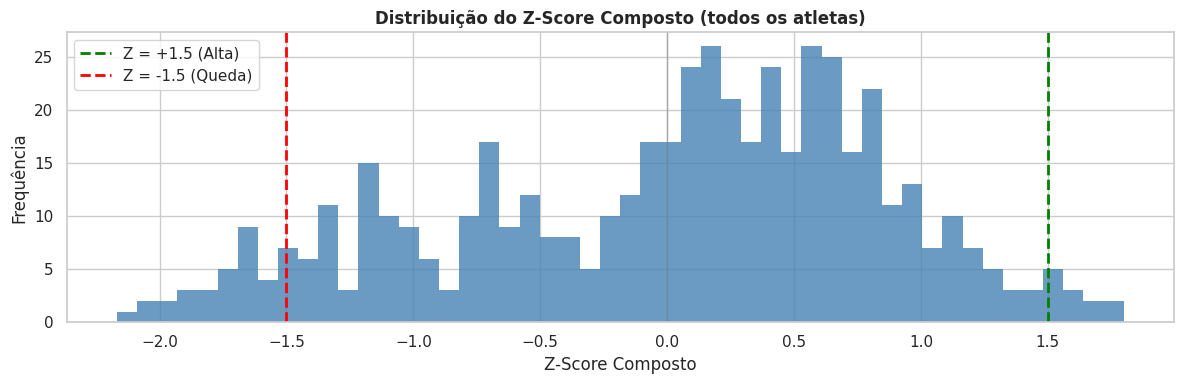

In [20]:
# ─────────────────────────────────────────────────────────
# PASSO 8.3 — Z-SCORE COMPOSTO (média dos Z-scores das variáveis-chave)
# ─────────────────────────────────────────────────────────
# Um Z-score composto resume o desempenho geral de uma sessão num único número.
# Usamos as variáveis de volume e intensidade mais representativas.

FEATURES_COMPOSTAS = [f for f in [
    'Distance (m)', 'Workload', 'High Intensity Running (m)',
    'Sprint Distance (m)', 'Accelerations', 'Decelerations'
] if f in FEATURES]

z_compostas = [f'Z_{f}' for f in FEATURES_COMPOSTAS]
df_zscores['Z_Composto'] = df_zscores[z_compostas].mean(axis=1)

print(f"📐 Z-Score Composto calculado como média de:")
for f in FEATURES_COMPOSTAS:
    print(f"   • Z_{f}")

print(f"\n📊 Distribuição do Z-Score Composto:")
print(df_zscores['Z_Composto'].describe().round(4).to_string())

# Histograma
fig, ax = plt.subplots(figsize=(12, 4))
df_zscores['Z_Composto'].hist(bins=50, ax=ax, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(x=1.5, color='green', linestyle='--', linewidth=2, label='Z = +1.5 (Alta)')
ax.axvline(x=-1.5, color='red', linestyle='--', linewidth=2, label='Z = -1.5 (Queda)')
ax.axvline(x=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
ax.set_title('Distribuição do Z-Score Composto (todos os atletas)', fontsize=12, fontweight='bold')
ax.set_xlabel('Z-Score Composto')
ax.set_ylabel('Frequência')
ax.legend()
plt.tight_layout()
plt.show()


---
## Seção 9 — Classificação Combinada: Isolation Forest + Z-Score

### Lógica de combinação

Cada método tem pontos fortes e fracos:

| Método | Pontos Fortes | Limitações |
|---|---|---|
| **Isolation Forest** | Detecta anomalias multivariadas complexas; não assume distribuição; robusto | Resultado binário (anômalo / normal); pouca interpretabilidade |
| **Z-Score** | Matematicamente interpretável; explica qual variável causou a anomalia | Assume distribuição aproximadamente normal; é univariado por padrão |

**Combinando os dois**, obtemos:
- A **detecção robusta** do Isolation Forest (captura padrões multivariados)
- A **explicabilidade** do Z-Score (diz por que é anômalo e em qual direção)

### Regras de classificação

```
SE IF_Anomalia = True  E  Z_Composto > +1.5  →  ALTA DE DESEMPENHO  ⬆️
SE IF_Anomalia = True  E  Z_Composto < -1.5  →  QUEDA DE DESEMPENHO ⬇️
SE IF_Anomalia = True  E  |Z_Composto| ≤ 1.5 →  DESEMPENHO MÉDIO    ➡️  (anomalia por padrão multivariado)
SE IF_Anomalia = False                        →  DESEMPENHO MÉDIO    ➡️
```

### Justificativa das regras

- **Alta de desempenho**: O modelo detectou comportamento fora do padrão **E** os indicadores estão acima da média histórica. Isso pode indicar pico de forma física, motivação extra ou condições externas favoráveis.
- **Queda de desempenho**: O modelo detectou anomalia **E** os indicadores estão abaixo do padrão. Sinal de alerta: pode indicar fadiga, lesão incipiente, doença ou desmotivação.
- **Desempenho médio com anomalia multivariada**: O Isolation Forest detectou padrão incomum, mas o Z-Score composto não é extremo. Isso acontece quando a *combinação* de variáveis é incomum, mas cada variável individualmente está dentro do esperado (ex.: muitas acelerações com baixa distância).


In [21]:
# ─────────────────────────────────────────────────────────
# CLASSIFICAÇÃO COMBINADA
# ─────────────────────────────────────────────────────────

def classificar_sessao(row, z_threshold=1.5):
    """
    Aplica as regras de negócio combinando Isolation Forest e Z-Score Composto.
    
    Args:
        row: linha do DataFrame com IF_Anomalia e Z_Composto
        z_threshold: limiar de Z para separar alta/queda de desempenho médio
    
    Returns:
        str: 'Alta de Desempenho', 'Queda de Desempenho' ou 'Desempenho Médio'
    """
    if pd.isna(row['IF_Anomalia']) or pd.isna(row['Z_Composto']):
        return 'Desempenho Médio'
    
    if row['IF_Anomalia']:
        if row['Z_Composto'] > z_threshold:
            return 'Alta de Desempenho'
        elif row['Z_Composto'] < -z_threshold:
            return 'Queda de Desempenho'
        else:
            return 'Desempenho Médio'
    else:
        return 'Desempenho Médio'

df_zscores['Classificacao'] = df_zscores.apply(classificar_sessao, axis=1)

# Sumário
dist_class = df_zscores['Classificacao'].value_counts()
print("📊 Distribuição das classificações:")
for classe, n in dist_class.items():
    emoji = '⬆️' if 'Alta' in classe else ('⬇️' if 'Queda' in classe else '➡️')
    print(f"   {emoji} {classe}: {n} sessões ({n/len(df_zscores)*100:.1f}%)")


📊 Distribuição das classificações:
   ➡️ Desempenho Médio: 476 sessões (93.0%)
   ⬇️ Queda de Desempenho: 26 sessões (5.1%)
   ⬆️ Alta de Desempenho: 10 sessões (2.0%)


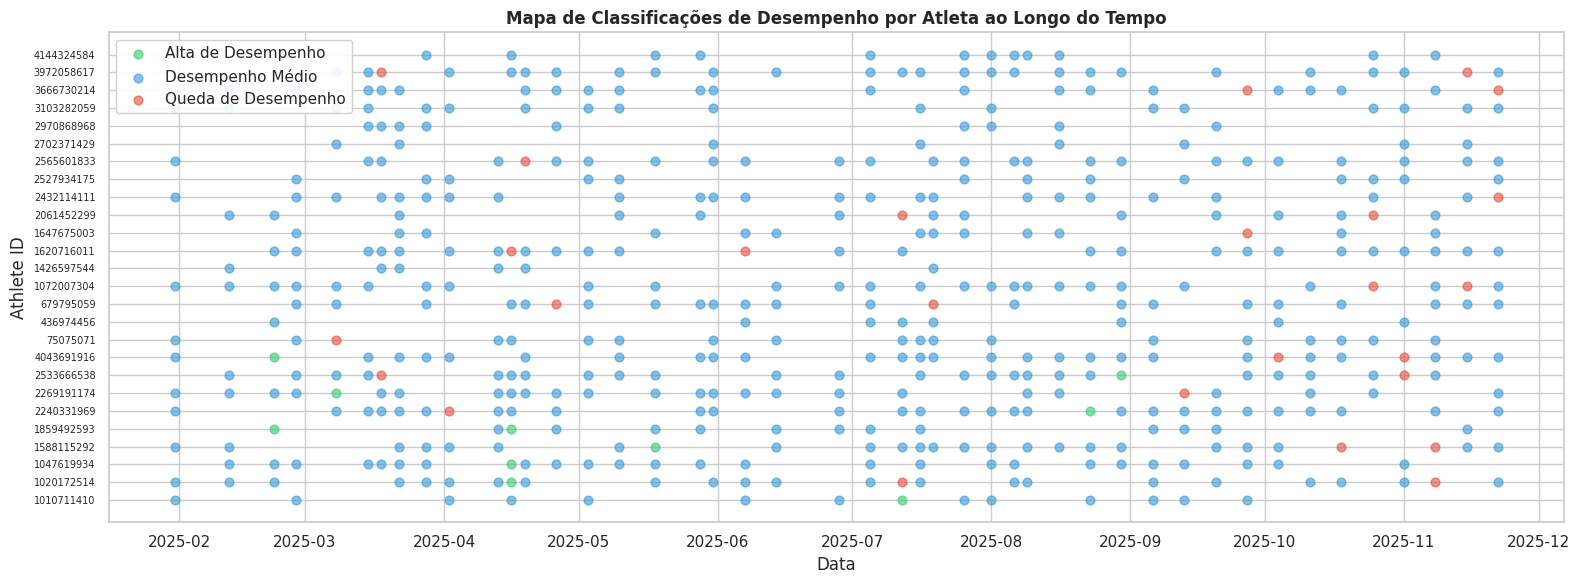

In [22]:
# ─────────────────────────────────────────────────────────
# VISUALIZAÇÃO: MAPA DE CLASSIFICAÇÕES POR ATLETA E TEMPO
# ─────────────────────────────────────────────────────────

# Agregar por atleta: contar cada categoria
cores_map = {
    'Alta de Desempenho': '#2ECC71',
    'Desempenho Médio': '#3498DB',
    'Queda de Desempenho': '#E74C3C'
}

fig, ax = plt.subplots(figsize=(16, 6))
for classe, cor in cores_map.items():
    subset = df_zscores[df_zscores['Classificacao'] == classe]
    ax.scatter(subset['Start Date'], subset['Athlete ID'].astype(str),
               c=cor, alpha=0.6, s=40, label=classe, zorder=3)

ax.set_title('Mapa de Classificações de Desempenho por Atleta ao Longo do Tempo',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Athlete ID')
plt.yticks(fontsize=7)
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()


In [23]:
# ─────────────────────────────────────────────────────────
# RELATÓRIO DETALHADO — SESSÕES ANÔMALAS
# ─────────────────────────────────────────────────────────

print("🔍 SESSÕES CLASSIFICADAS COMO 'QUEDA DE DESEMPENHO':")
print("="*80)

quedas = df_zscores[df_zscores['Classificacao'] == 'Queda de Desempenho'].sort_values('Z_Composto')
colunas_rel = ['Athlete ID', 'Start Date', 'Z_Composto', 'IF_Score'] + z_compostas[:4]
colunas_rel = [c for c in colunas_rel if c in quedas.columns]

if len(quedas) > 0:
    print(quedas[colunas_rel].head(10).round(3).to_string(index=False))
else:
    print("Nenhuma queda de desempenho detectada com os thresholds atuais.")

print()
print("🔍 SESSÕES CLASSIFICADAS COMO 'ALTA DE DESEMPENHO':")
print("="*80)

altas = df_zscores[df_zscores['Classificacao'] == 'Alta de Desempenho'].sort_values('Z_Composto', ascending=False)
if len(altas) > 0:
    print(altas[colunas_rel].head(10).round(3).to_string(index=False))
else:
    print("Nenhuma alta de desempenho detectada com os thresholds atuais.")


🔍 SESSÕES CLASSIFICADAS COMO 'QUEDA DE DESEMPENHO':
 Athlete ID Start Date  Z_Composto  IF_Score  Z_Distance (m)  Z_Workload  Z_High Intensity Running (m)  Z_Sprint Distance (m)
 2533666538 2025-11-01      -2.169    -0.678          -2.559      -2.882                        -1.749                 -1.280
 1072007304 2025-11-15      -2.086    -0.666          -2.247      -2.732                        -1.920                 -1.353
 1620716011 2025-06-07      -2.064    -0.626          -2.216      -2.553                        -1.864                 -1.402
 2240331969 2025-04-02      -1.972    -0.675          -2.190      -2.468                        -1.894                 -1.209
 2533666538 2025-03-18      -1.952    -0.621          -2.203      -2.574                        -1.602                 -1.280
 2061452299 2025-07-12      -1.922    -0.654          -2.119      -2.331                        -1.784                 -1.235
 2269191174 2025-09-13      -1.905    -0.654          -2.180      

---
## Seção 10 — Comparação entre Atletas e Sugestão de Substitutos

### Objetivo

Dado um atleta de referência (ex.: atleta lesionado ou suspenso), encontrar o atleta do elenco cujo **perfil de desempenho** é mais similar, permitindo ao técnico tomar decisões de escalação informadas.

### Representação do perfil de um atleta

Cada atleta é representado por um **vetor de perfil** — a média de seus indicadores padronizados ao longo de toda a temporada:

$$\vec{p}_i = \left[\bar{z}_{\text{Workload}}, \bar{z}_{\text{Distance}}, \bar{z}_{\text{Sprint}}, \ldots\right]_i$$

### Medidas de similaridade utilizadas

#### 1. Distância Euclidiana

$$d_{\text{eucl}}(\vec{a}, \vec{b}) = \sqrt{\sum_{k=1}^{n}(a_k - b_k)^2}$$

**Interpretação**: mede a distância "em linha reta" no espaço n-dimensional dos indicadores. Quanto menor, mais similar. Sensível à magnitude das diferenças.

#### 2. Distância de Cosseno

$$d_{\text{cos}}(\vec{a}, \vec{b}) = 1 - \frac{\vec{a} \cdot \vec{b}}{|\vec{a}||\vec{b}|}$$

**Interpretação**: mede o ângulo entre os vetores de perfil. Quanto menor, mais similar o *padrão* de desempenho (independente da magnitude). Um atacante veloz e intenso será similar a outro atacante com o mesmo padrão, mesmo que um seja mais rápido que o outro.

### Combinação das métricas

Usamos uma **pontuação de similaridade combinada**:

$$\text{Sim} = \frac{1}{1 + d_{\text{eucl}}} \times (1 - d_{\text{cos}})$$

Valores próximos de 1 indicam alta similaridade em ambas as métricas.


In [24]:
# ─────────────────────────────────────────────────────────
# PASSO 10.1 — CONSTRUÇÃO DOS VETORES DE PERFIL
# ─────────────────────────────────────────────────────────
# Cada atleta é representado pela média de seus Z-Scores históricos.
# Isso captura o padrão relativo de desempenho de cada jogador.

perfis = df_zscores.groupby('Athlete ID')[z_cols].mean()

print(f"✅ Perfis construídos para {len(perfis)} atletas")
print(f"   Dimensão do vetor de perfil: {len(z_cols)} variáveis")
print()
print("📊 Primeiros 3 atletas — vetores de perfil (Z-Score médio por variável):")
print(perfis.head(3).round(3).to_string())


✅ Perfis construídos para 26 atletas
   Dimensão do vetor de perfil: 11 variáveis

📊 Primeiros 3 atletas — vetores de perfil (Z-Score médio por variável):
            Z_Workload  Z_Distance (m)  Z_Metres per Minute (m)  Z_High Intensity Running (m)  Z_Sprint Distance (m)  Z_Top Speed (kph)  Z_Avg Speed (kph)  Z_Accelerations  Z_Decelerations  Z_No. of Sprints  Z_Duration (mins)
Athlete ID                                                                                                                                                                                                                       
75075071          -0.0            -0.0                      0.0                           0.0                    0.0               -0.0               -0.0              0.0             -0.0               0.0               -0.0
436974456          0.0             0.0                      0.0                           0.0                    0.0                0.0               -0.0             

📐 Matrizes de distância calculadas:
   Euclidiana: (26, 26) — valores em [0.00, 0.00]
   Cosseno:    (26, 26) — valores em [0, 1.0000]


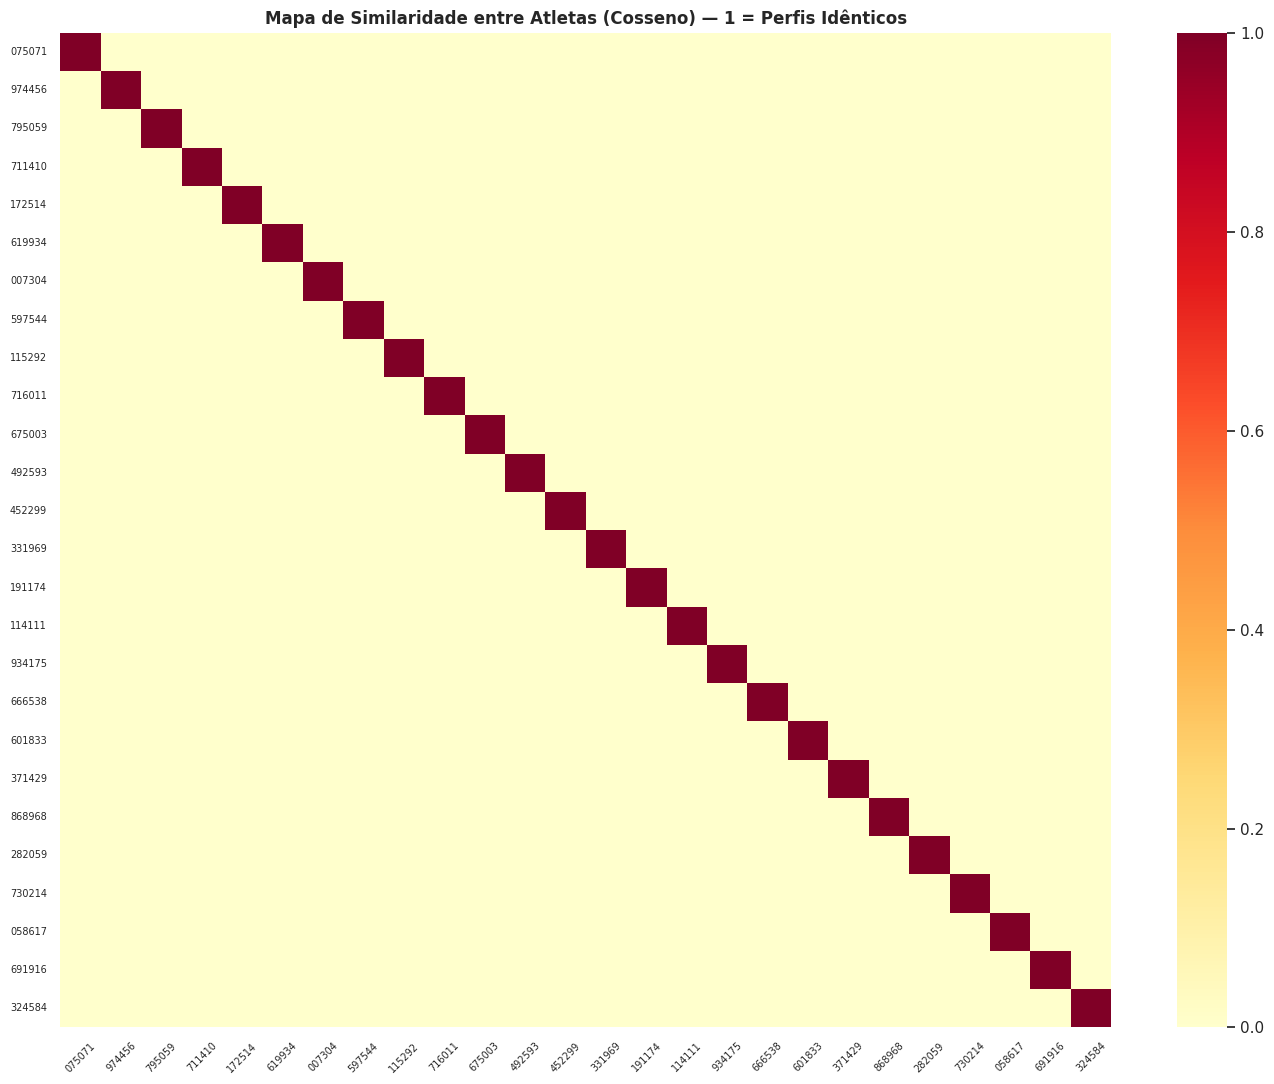

In [25]:
# ─────────────────────────────────────────────────────────
# PASSO 10.2 — MATRIZES DE SIMILARIDADE
# ─────────────────────────────────────────────────────────

X_perfis = perfis.values
ids_atletas = perfis.index.tolist()

# Distância Euclidiana
dist_eucl = euclidean_distances(X_perfis)
df_eucl = pd.DataFrame(dist_eucl, index=ids_atletas, columns=ids_atletas)

# Distância de Cosseno
dist_cos = cosine_distances(X_perfis)
df_cos = pd.DataFrame(dist_cos, index=ids_atletas, columns=ids_atletas)

print("📐 Matrizes de distância calculadas:")
print(f"   Euclidiana: {df_eucl.shape} — valores em [{df_eucl.values[df_eucl.values > 0].min():.2f}, {df_eucl.values.max():.2f}]")
print(f"   Cosseno:    {df_cos.shape} — valores em [0, {df_cos.values.max():.4f}]")

# Heatmap de similaridade (cosseno)
sim_cos = 1 - dist_cos  # Converter distância → similaridade
df_sim = pd.DataFrame(sim_cos, index=ids_atletas, columns=ids_atletas)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(df_sim, annot=False, cmap='YlOrRd', ax=ax,
            xticklabels=[str(a)[-6:] for a in ids_atletas],
            yticklabels=[str(a)[-6:] for a in ids_atletas])
ax.set_title('Mapa de Similaridade entre Atletas (Cosseno) — 1 = Perfis Idênticos', 
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()
plt.show()


In [26]:
# ─────────────────────────────────────────────────────────
# PASSO 10.3 — FUNÇÃO DE SUGESTÃO DE SUBSTITUTOS
# ─────────────────────────────────────────────────────────

def sugerir_substitutos(atleta_referencia, perfis, dist_eucl_df, dist_cos_df, top_n=3):
    """
    Dado um atleta de referência, retorna os N atletas mais similares.
    
    Args:
        atleta_referencia: ID do atleta que precisa de substituto
        perfis: DataFrame com vetores de perfil
        dist_eucl_df: DataFrame com distâncias euclidianas
        dist_cos_df: DataFrame com distâncias de cosseno
        top_n: número de substitutos a sugerir
    
    Returns:
        DataFrame com os substitutos e suas pontuações de similaridade
    """
    if atleta_referencia not in perfis.index:
        print(f"❌ Atleta {atleta_referencia} não encontrado nos perfis.")
        return None
    
    outros = [a for a in perfis.index if a != atleta_referencia]
    
    resultados = []
    for outro in outros:
        d_eucl = dist_eucl_df.loc[atleta_referencia, outro]
        d_cos = dist_cos_df.loc[atleta_referencia, outro]
        
        # Score combinado: penaliza tanto distância euclidiana quanto angular
        sim_eucl = 1 / (1 + d_eucl)   # 0 a 1, maior = mais similar
        sim_cos = max(0, 1 - d_cos)    # 0 a 1, maior = mais similar
        score = (sim_eucl * 0.4 + sim_cos * 0.6)  # Ponderado: cosseno tem mais peso
        
        resultados.append({
            'Atleta Candidato': outro,
            'Distância Euclidiana': d_eucl,
            'Distância Cosseno': d_cos,
            'Similaridade (0-1)': score
        })
    
    df_res = pd.DataFrame(resultados).sort_values('Similaridade (0-1)', ascending=False)
    return df_res.head(top_n)

# Demonstração: atleta com mais sessões como referência
atleta_ref = df_zscores.groupby('Athlete ID').size().idxmax()

print(f"🔍 Sugestão de substitutos para o Atleta {atleta_ref}")
print("="*70)
substitutos = sugerir_substitutos(atleta_ref, perfis, df_eucl, df_cos, top_n=5)
if substitutos is not None:
    print(substitutos.round(4).to_string(index=False))
print()
print("💡 O candidato com maior 'Similaridade (0-1)' é o melhor substituto")
print("   funcional — aquele cujo padrão de desempenho mais se aproxima do")
print("   atleta de referência em termos de volume, intensidade e padrão físico.")


🔍 Sugestão de substitutos para o Atleta 2240331969
 Atleta Candidato  Distância Euclidiana  Distância Cosseno  Similaridade (0-1)
       1072007304                   0.0                1.0                 0.4
       2533666538                   0.0                1.0                 0.4
       1588115292                   0.0                1.0                 0.4
       1620716011                   0.0                1.0                 0.4
       1859492593                   0.0                1.0                 0.4

💡 O candidato com maior 'Similaridade (0-1)' é o melhor substituto
   funcional — aquele cujo padrão de desempenho mais se aproxima do
   atleta de referência em termos de volume, intensidade e padrão físico.


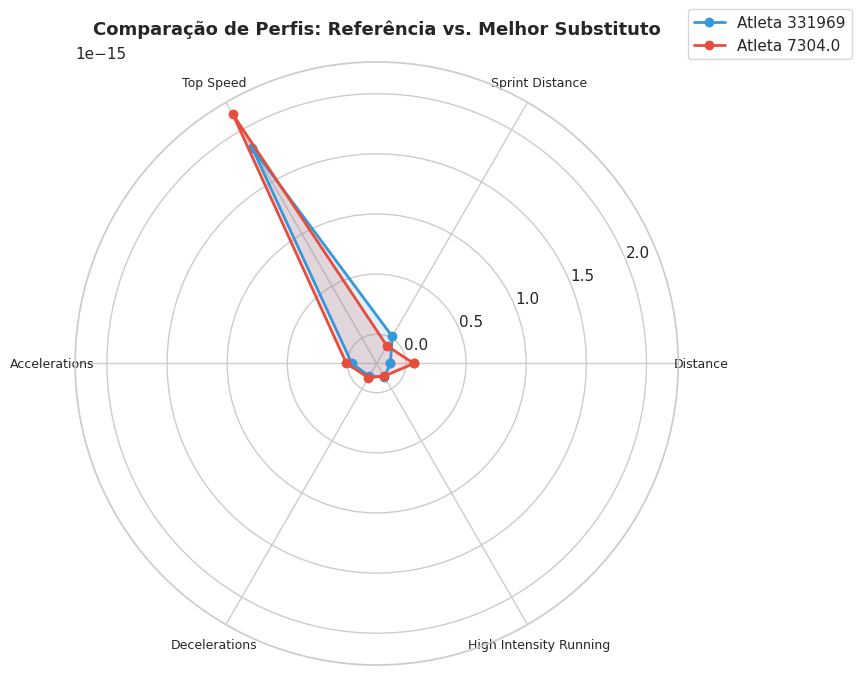

In [27]:
# ─────────────────────────────────────────────────────────
# PASSO 10.4 — VISUALIZAÇÃO RADAR: COMPARAÇÃO DE PERFIS
# ─────────────────────────────────────────────────────────

import matplotlib.patches as mpatches

def radar_chart(atletas, perfis_df, features_radar, titulo='Comparação de Perfis'):
    """Gera gráfico radar comparando perfis de múltiplos atletas."""
    
    n = len(features_radar)
    angulos = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angulos += angulos[:1]  # Fechar o polígono
    
    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
    
    cores = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']
    
    for i, atleta in enumerate(atletas):
        if atleta not in perfis_df.index:
            continue
        valores = perfis_df.loc[atleta, [f'Z_{f}' for f in features_radar if f'Z_{f}' in perfis_df.columns]].values.tolist()
        valores += valores[:1]
        
        ax.plot(angulos, valores, 'o-', linewidth=2, color=cores[i % len(cores)], label=f'Atleta {str(atleta)[-6:]}')
        ax.fill(angulos, valores, alpha=0.15, color=cores[i % len(cores)])
    
    labels_radar = [f.replace(' (m)', '').replace(' (kph)', '').replace('No. of ', '') for f in features_radar]
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(labels_radar, size=9)
    ax.set_title(titulo, size=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# Features para o radar
features_radar = [f for f in ['Distance (m)', 'Sprint Distance (m)', 'Top Speed (kph)', 
                               'Accelerations', 'Decelerations', 'High Intensity Running (m)'] if f in FEATURES]

# Comparar atleta referência com seu melhor substituto
if substitutos is not None:
    atleta_sub = substitutos.iloc[0]['Atleta Candidato']
    radar_chart(
        [atleta_ref, atleta_sub],
        perfis, features_radar,
        titulo=f'Comparação de Perfis: Referência vs. Melhor Substituto'
    )


---
## Seção 11 — Resumo Executivo e Próximos Passos

### O que foi construído nesta PoC

Este notebook implementou e documentou um pipeline analítico completo para monitoramento de desempenho de atletas:

| Etapa | O que foi feito | Resultado |
|---|---|---|
| **Importação** | Leitura do Excel, filtro de Whole Session | Dataset limpo e segmentado |
| **Data Quality** | Tratamento de ausentes, zeros, duplicatas, inconsistências | Base confiável para modelagem |
| **Features** | Seleção de 11 indicadores físicos com justificativa esportiva | Features relevantes e interpretáveis |
| **StandardScaler** | Padronização para média=0, desvio=1 | Comparabilidade entre atletas |
| **Estatísticas** | Média, mediana, desvio, variância por atleta | Perfil histórico individual |
| **Isolation Forest** | Detecção de sessões anômalas por atleta | Sessões classificadas como normal/anomalia |
| **Z-Score** | Quantificação matemática da distância da média | Direção e magnitude da anomalia |
| **Classificação** | Combinação IF + Z-Score em 3 classes | Alta / Médio / Queda de desempenho |
| **Substitutos** | Distâncias euclidiana e de cosseno entre perfis | Top N atletas mais similares |

### Limitações desta PoC

1. **Volume de dados**: Com poucos registros por atleta, o Isolation Forest pode ser menos preciso. Recomendamos mínimo de 20 sessões por jogador.
2. **Contexto não capturado**: Adversário, temperatura, altitude, e dias de descanso influenciam o desempenho mas não estão na base atual.
3. **Calibração de thresholds**: Os thresholds (contamination=0.1, Z=±1.5) foram definidos como ponto de partida — devem ser ajustados com feedback do corpo técnico.
4. **Sazonalidade**: O modelo não distingue pré-temporada de temporada competitiva.

### Roadmap para a aplicação web

```
PoC (este notebook)
    │
    ├─► API REST (FastAPI/Django) 
    │       └─► Endpoints: /analyze/{atleta_id}, /substitutes/{atleta_id}
    │
    ├─► Banco de Dados (PostgreSQL/TimescaleDB)
    │       └─► Histórico de sessões, scores, classificações
    │
    ├─► Dashboard (React + Recharts/D3.js)
    │       └─► Gráficos interativos, radar de perfil, linha do tempo
    │
    ├─► Sistema de Alertas (email/push notification)
    │       └─► Alerta automático em 'Queda de Desempenho'
    │
    └─► Autenticação (JWT + RBAC)
            └─► Perfis: Técnico, Preparador Físico, Médico, Admin
```

### Conceito de alerta (como seria na aplicação web)

```python
# Pseudocódigo — não executável nesta PoC
def verificar_e_alertar(atleta_id, nova_sessao):
    classificacao = pipeline.predict(atleta_id, nova_sessao)
    if classificacao == 'Queda de Desempenho':
        alerta = {
            'tipo': 'QUEDA_DESEMPENHO',
            'atleta': atleta_id,
            'sessao': nova_sessao['data'],
            'z_score': nova_sessao['Z_Composto'],
            'variaveis_criticas': identificar_variaveis_criticas(nova_sessao),
            'urgencia': 'ALTA' if nova_sessao['Z_Composto'] < -2.5 else 'MEDIA'
        }
        notificar_preparador_fisico(alerta)
        registrar_no_banco(alerta)
```


In [28]:
# ─────────────────────────────────────────────────────────
# EXPORTAÇÃO DO DATASET FINAL COM TODAS AS ANÁLISES
# ─────────────────────────────────────────────────────────

colunas_export = (
    ['Athlete ID', 'Athlete Position', 'Start Date', 'Duration (mins)']
    + FEATURES
    + ['IF_Score', 'IF_Anomalia', 'Z_Composto', 'Classificacao']
    + z_cols[:6]  # Primeiros 6 Z-Scores individuais
)
colunas_export = [c for c in colunas_export if c in df_zscores.columns]

df_export = df_zscores[colunas_export].copy()
df_export.to_excel('resultados_pipeline.xlsx', index=False)

print("💾 Dataset com resultados exportado: 'resultados_pipeline.xlsx'")
print(f"   Linhas: {len(df_export):,} | Colunas: {len(df_export.columns)}")
print()

# Resumo final
print("="*60)
print("   RESUMO FINAL DO PIPELINE")
print("="*60)
print(f"   Atletas analisados       : {df_zscores['Athlete ID'].nunique()}")
print(f"   Sessões processadas      : {len(df_zscores):,}")
print(f"   Período                  : {df_zscores['Start Date'].min().date()} → {df_zscores['Start Date'].max().date()}")
print(f"   Variáveis no modelo      : {len(FEATURES)}")
print()
for classe in ['Alta de Desempenho', 'Desempenho Médio', 'Queda de Desempenho']:
    n = (df_zscores['Classificacao'] == classe).sum()
    emoji = '⬆️' if 'Alta' in classe else ('⬇️' if 'Queda' in classe else '➡️')
    print(f"   {emoji} {classe:25s}: {n:4d} sessões ({n/len(df_zscores)*100:.1f}%)")
print("="*60)
print("\n✅ Pipeline completo executado com sucesso!")


💾 Dataset com resultados exportado: 'resultados_pipeline.xlsx'
   Linhas: 512 | Colunas: 25

   RESUMO FINAL DO PIPELINE
   Atletas analisados       : 26
   Sessões processadas      : 512
   Período                  : 2025-01-31 → 2025-11-22
   Variáveis no modelo      : 11

   ⬆️ Alta de Desempenho       :   10 sessões (2.0%)
   ➡️ Desempenho Médio         :  476 sessões (93.0%)
   ⬇️ Queda de Desempenho      :   26 sessões (5.1%)

✅ Pipeline completo executado com sucesso!
